#### Q.From the Dataset provided predict no. of Passenger for the 5 Years, month wise

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from numpy import log
from pandas import Series
from datetime import datetime

In [2]:
dataset=pd.read_csv('/Users/yashgurung/LearnBay/Time Series/csv files/AirPassenger1.csv')
dataset.tail()

,Year-Month,Pax
139,1960-Aug,606
140,1960-Sep,508
141,1960-Oct,461
142,1960-Nov,390
143,1960-Dec,432


- #### **Conversion of Time feature into datetime format, and setting it as Index**

In [3]:
dataset.dtypes

Year-Month    object
Pax            int64
dtype: object

In [4]:
dataset['Year-Month']=pd.to_datetime(dataset['Year-Month'])

In [5]:
dataset=dataset.set_index('Year-Month')
dataset.tail()

,Pax
Year-Month,
1960-08-01,606
1960-09-01,508
1960-10-01,461
1960-11-01,390
1960-12-01,432


- #### **Overall View of the dataset given**

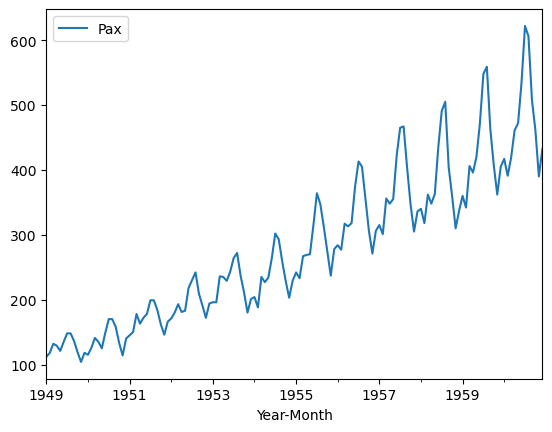

In [6]:
dataset.plot()
plt.show()

From the given data, we can already determine:
- Trend: Upward Trend
- Seasonality: Possibility, since we are observing Zenith Point and Nadir Point for every Year i.e parituclar month we are seeing highest and lowest passengers for each year.

**NOTE:**  
- Zenith Point: Highest Peak within a recurring cycle  
- Nadir Point: Lowest Peak within a recurring cycle

- #### **Decomposition: To check for TSF Components**

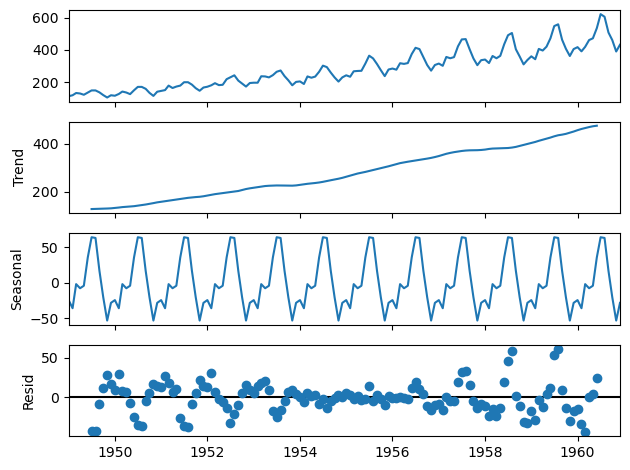

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose
decom_add=seasonal_decompose(dataset,model='additive',period=12) 
#dataset parameter: dependent/target variable
#period=12, since seasonal component is max 12 months Data

decom_add.plot()
plt.show()

The plot confirms the dataset has Trend, Seasonality and Residuals/Noise data.  
With contigous maximum Seasnality and Noise difference of 50

**NOTE**
In Time Series Forecasting, Durby Watson Test, to check for autocorrelation is a must

- #### **Durbin Watson Test**

In [8]:
import statsmodels.api as sm
sm.stats.durbin_watson(dataset['Pax'])

np.float64(0.0121527966037621)

 - Since **DBT value <2**, we can state that the Target variable is **highly +ve auto-correlated**
 - Thus Regression Model is Invalid due to OLS error, **TimeSeriesForcasting** needs to be done(Since there is TimeData)

- #### **Checking and Conversion of Time Date into Stationary**  
Since we are building TimeSeriesForecasting Model

1. **Augmented Dickey Fuller Test**  
To check Time Data, is stationary or not

In [9]:
from statsmodels.tsa.stattools import adfuller
adfuller(dataset['Pax'])

(np.float64(0.8153688792060523),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

In [10]:
#Creating function to show result of  ADF Test in presenatable manner

def ADFT(data):
    print('Augmented Dickey Fuller Test:')
    res=adfuller(data)
    labels=['ADF Stats Test','p-value','Lag','No. of Observation']

    for i,j in zip(res,labels):
        print(j+' = '+str(i))
        
    print('-'*50)
    
    if res[1]<0.05:
        print('Reject Null Hypothesis, and Time Series Data is Stationary')
    elif res[1]>0.05:
        print('Fail to Reject Null Hypothesis, and Time Series Data is Non-Stationary')

In [11]:
ADFT(dataset['Pax'])

Augmented Dickey Fuller Test:
ADF Stats Test = 0.8153688792060523
p-value = 0.991880243437641
Lag = 13
No. of Observation = 130
--------------------------------------------------
Fail to Reject Null Hypothesis, and Time Series Data is Non-Stationary


#### Calculation of d and D parameters

2. **Lag Difference Function**  
Lag= previous value of the data, similar to SQL Window function lag()  
Difference= Diff b/w orignal & Lag values

In [12]:
dataset['1st Diff']=dataset['Pax']-dataset['Pax'].shift(1)
#Basically row1 -row0 and so on...

#1st row value - Null = Null

dataset.head()

,Pax,1st Diff
Year-Month,,
1949-01-01,112,NaN
1949-02-01,118,6.0
1949-03-01,132,14.0
1949-04-01,129,-3.0
1949-05-01,121,-8.0


##### 2.1 **Checking the new 1st Diff feature using ADFT**

In [13]:
ADFT(dataset['1st Diff'].dropna())
#Since any TSF methods cannot work with null values

Augmented Dickey Fuller Test:
ADF Stats Test = -2.829266824169988
p-value = 0.05421329028382705
Lag = 12
No. of Observation = 130
--------------------------------------------------
Fail to Reject Null Hypothesis, and Time Series Data is Non-Stationary


**NOTE**  
p-value dropped from 0.99 to 0.54 using level 1 Lag Difference

##### 2.2 **Checking the new 2nd Diff feature using ADFT**  
Since Level1 was not enough for stationary

In [14]:
dataset['2nd Diff']=dataset['1st Diff']-dataset['1st Diff'].shift(1)
dataset.head()

,Pax,1st Diff,2nd Diff
Year-Month,,,
1949-01-01,112,NaN,NaN
1949-02-01,118,6.0,NaN
1949-03-01,132,14.0,8.0
1949-04-01,129,-3.0,-17.0
1949-05-01,121,-8.0,-5.0


In [15]:
ADFT(dataset['2nd Diff'].dropna())

Augmented Dickey Fuller Test:
ADF Stats Test = -16.3842315424685
p-value = 2.73289185001424e-29
Lag = 11
No. of Observation = 130
--------------------------------------------------
Reject Null Hypothesis, and Time Series Data is Stationary


- Since we required 2step difference to make time series stationary,  
- hence the parameter **d**=2, for the Integreated/Difference model

#### 3.Seasonality
Since the given dataset consists of seasonality

In [16]:
dataset['Seasonality']=dataset['Pax']-dataset['Pax'].shift(12) 
#since seasonality is of 12 months period max

dataset.head(24)

,Pax,1st Diff,2nd Diff,Seasonality
Year-Month,,,,
1949-01-01,112,NaN,NaN,NaN
1949-02-01,118,6.0,NaN,NaN
1949-03-01,132,14.0,8.0,NaN
1949-04-01,129,-3.0,-17.0,NaN
1949-05-01,121,-8.0,-5.0,NaN
1949-06-01,135,14.0,22.0,NaN
1949-07-01,148,13.0,-1.0,NaN
1949-08-01,148,0.0,-13.0,NaN
1949-09-01,136,-12.0,-12.0,NaN


##### 3.1 **Checking the new Seasonality feature using ADFT**

In [17]:
ADFT(dataset['Seasonality'].dropna())

Augmented Dickey Fuller Test:
ADF Stats Test = -3.3830207264924805
p-value = 0.011551493085514978
Lag = 1
No. of Observation = 130
--------------------------------------------------
Reject Null Hypothesis, and Time Series Data is Stationary


- hence the parameter **D**=1, for the Integreated/Difference model

#### Calculation of Trend parameters p,q

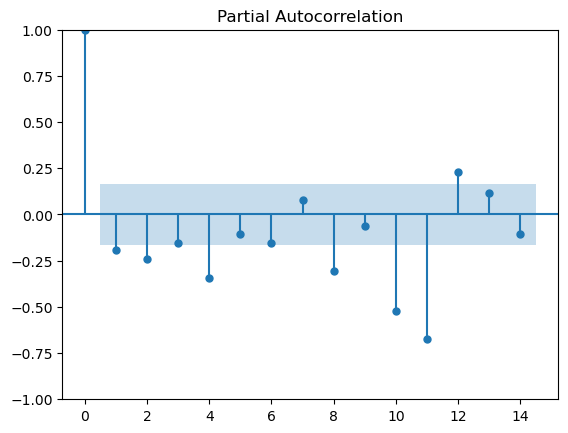

In [18]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

#TREND: p
plot_pacf(dataset['2nd Diff'].dropna(),lags=14)
#lags: 2 times the seasonality or 25%-50% of entier observation of dataset

plt.show()

**NOTE**
1. Y-axis: Correlation -1 to +1
2. 0th Line: Actual Data
3. Reference Band: Lines that comes within this range has no PAC. [0.20 - -0.20]
4. for p:  
   count the no. of dots that are touching or above the Reference Band, till dot that is within the band/range. For above its **p parameter=4**


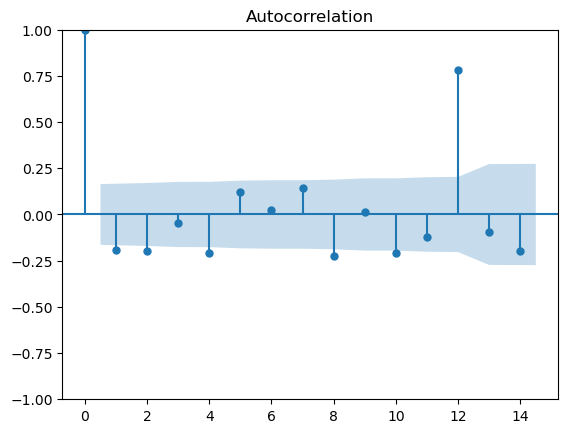

In [19]:
#TREND q:
plot_acf(dataset['2nd Diff'].dropna(),lags=14)
plt.show()

**NOTE**
1. for q:  
   count the no. of dots that are touching or above the Reference Band, till dot that is within the band/range. For above its **q parameter=2**

#### Calculation of Seasonality parameters P,Q

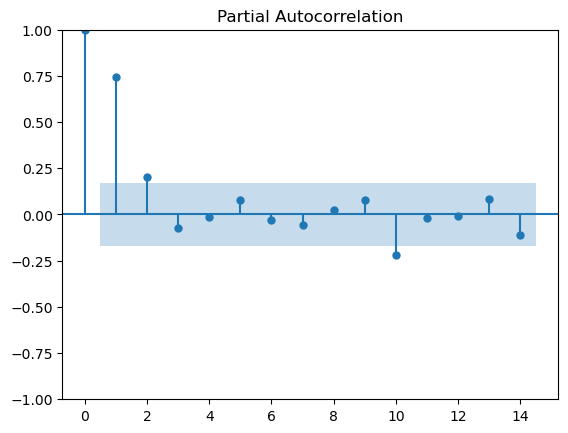

In [20]:
plot_pacf(dataset['Seasonality'].dropna(),lags=14)
plt.show()

**NOTE**
1. for P:  
   count the no. of dots that are touching or above the Reference Band, till dot that is within the band/range. For above its **P parameter=2**

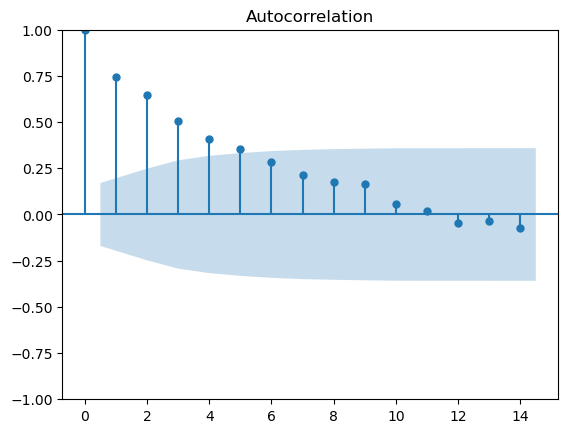

In [21]:
plot_acf(dataset['Seasonality'].dropna(),lags=14)
plt.show()

**NOTE**
1. for Q:  
   count the no. of dots that are touching or above the Reference Band, till dot that is within the band/range. For above its **Q parameter=5**

**HENCE**
- TREND:
  - p:4 , q:2 , d:2
- SEASONALITY:
  - P:2 , Q:5 , D:1
 
- d/D : Durbey Watson Test -> Augemented Dickey Fuller Test
- pP,qQ: statsmodel.graphics.tsaplots

### - **ARIMA Model**

In [22]:
from statsmodels.tsa.arima_model import ARIMA
model=sm.tsa.statespace.SARIMAX(dataset['Pax'], order=(4,2,2),seasonal_order=(2,1,1,12))
#order=Trend's pdq
#seasonal_order=Seasonal's PDQ and Max period in months
result=model.fit()

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Since there is Seasonality in the data, we will use SARIMAX which is within ARIMA itself, and External factor also we will add, to be on safer side, since there is residuals.

In [23]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                  Pax   No. Observations:                  144
Model:             SARIMAX(4, 2, 2)x(2, 1, [1], 12)   Log Likelihood                -497.783
Date:                              Tue, 25 Aug 2026   AIC                           1015.566
Time:                                      00:09:49   BIC                           1044.242
Sample:                                  01-01-1949   HQIC                          1027.218
                                       - 12-01-1960                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.3587      0.097    -14.054      0.000      -1.548      -1.169
ar.L2         -0.4918      0.145     -3.384      0.001      -0.777      -0.207
ar.L3         -0.1171      0.172     -0.680      0.496      -0.454       0.220
ar.L4         -0.0681      0.097     -0.705      0.481      -0.258       0.121
ma.L1         -0.0021      0.869     -0.002      0.998      -1.706       1.702
ma.L2         -0.9979      0.935     -1.067      0.286      -2.831       0.835
ar.S.L12       0.6822      0.177      3.863      0.000       0.336       1.028
ar.S.L24       0.3160      0.104      3.050      0.002       0.113       0.519
ma.S.L12      -0.9686      1.135     -0.853      0.394      -3.193       1.256
sigma2       104.2337    108.555      0.960      0.337    -108.530     316.997
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                12.68
Prob(Q):                              0.82   Prob(JB):                         0.00
Heteroskedasticity (H):               2.75   Skew:                             0.23
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.46
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**NOTE**  
```SARIMAX(4, 2, 2)x(2, 1, [1, 2, 3, 4, 5], 12)```  
(4,2,2) = Trend pdq
(2,1,[1,2,3,4,5],12) = Seasonality PD[Q1,Q2,Q3,Q4,Q5],Period, where machine is suggeting to try with 1,2,3,4 also instead of 5, to get the best AIC value
- Lower the values of AIC and BIC better is the model

#### Manually Checking for the best Hyperparameters**

**Therefore, when we use provided other values of Q**  
pdq=4,2,2 PDQ=2,1,5,12 : AIC = 1021.436  
pdq=4,2,2 PDQ=2,1,4,12 : AIC = 1020.037  
pdq=4,2,2 PDQ=2,1,3,12 : AIC = 1018.373  
pdq=4,2,2 PDQ=2,1,2,12 : AIC = 1017.566    
**pdq=4,2,2 PDQ=2,1,1,12 : AIC = 1015.566** -> Best Parameter for the TSF model

#### Automative method to check the best hyperparameter values for AIC minimum
Can take upto an hour

import itertools

p=d=q=range(0,4) 
#4 since it is the max value out of all the parameters

pdq=list(itertools.product(p,d,q))
seasonal_pdq=[(x[0],x[1],x[2],12) for x in pdq]

for param_trend in pdq:
    for param_seasonality in seasonal_pdq:
        try:
            model=sm.tsa.statespace.SARIMAX(dataset['Pax'],order=param_trend,
                                            seasonal_order=param_seasonality,
                                            enforce_stationary=False,
                                            enforce_invertibility=False)
            result_auto=model.fit()
            print(f'ARIMA{param_trend}*{param_seasonality}: AIC: {result_auto.aic}')
        except:
            continue

In [24]:
dataset.tail()

,Pax,1st Diff,2nd Diff,Seasonality
Year-Month,,,,
1960-08-01,606,-16.0,-103.0,47.0
1960-09-01,508,-98.0,-82.0,45.0
1960-10-01,461,-47.0,51.0,54.0
1960-11-01,390,-71.0,-24.0,28.0
1960-12-01,432,42.0,113.0,27.0


#### - **Prediction of 1st Jan 1961 till 1st Dec 1965**

- Validation of the model using training Data

<Axes: xlabel='Year-Month'>

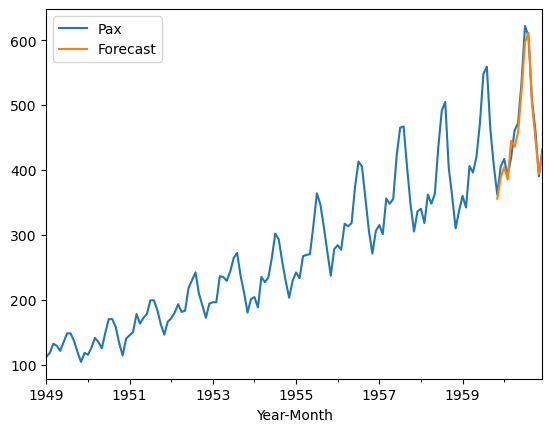

In [25]:
dataset['Forecast']=result.predict(start=130,end=144,dynamic=True)
#taking 130th till 144th rows as Testing Prediction data
#Then comparing it with the actual data of 130th till 144th rows
#dynamic=True makes future predicted plot into different colour

dataset[['Pax','Forecast']].plot()

Clearly, the model prediction accuracy is high with slight variance.  
It depends upon the correct pdq,PDQ parameter values.

- **Prediction of the future data**

In [26]:
dataset.tail()

,Pax,1st Diff,2nd Diff,Seasonality,Forecast
Year-Month,,,,,
1960-08-01,606,-16.0,-103.0,47.0,611.512382
1960-09-01,508,-98.0,-82.0,45.0,503.440194
1960-10-01,461,-47.0,51.0,54.0,448.442056
1960-11-01,390,-71.0,-24.0,28.0,393.165950
1960-12-01,432,42.0,113.0,27.0,426.459059


- **Adding future dates**

In [30]:
from pandas.tseries.offsets import DateOffset

future_data=[dataset.index[-1] + DateOffset(months=x) for x in range(0,61)]
#index[-1] : Last obersvation of the data given
#x=0  is the last given data.
future_data

[Timestamp('1960-12-01 00:00:00'),
 Timestamp('1961-01-01 00:00:00'),
 Timestamp('1961-02-01 00:00:00'),
 Timestamp('1961-03-01 00:00:00'),
 Timestamp('1961-04-01 00:00:00'),
 Timestamp('1961-05-01 00:00:00'),
 Timestamp('1961-06-01 00:00:00'),
 Timestamp('1961-07-01 00:00:00'),
 Timestamp('1961-08-01 00:00:00'),
 Timestamp('1961-09-01 00:00:00'),
 Timestamp('1961-10-01 00:00:00'),
 Timestamp('1961-11-01 00:00:00'),
 Timestamp('1961-12-01 00:00:00'),
 Timestamp('1962-01-01 00:00:00'),
 Timestamp('1962-02-01 00:00:00'),
 Timestamp('1962-03-01 00:00:00'),
 Timestamp('1962-04-01 00:00:00'),
 Timestamp('1962-05-01 00:00:00'),
 Timestamp('1962-06-01 00:00:00'),
 Timestamp('1962-07-01 00:00:00'),
 Timestamp('1962-08-01 00:00:00'),
 Timestamp('1962-09-01 00:00:00'),
 Timestamp('1962-10-01 00:00:00'),
 Timestamp('1962-11-01 00:00:00'),
 Timestamp('1962-12-01 00:00:00'),
 Timestamp('1963-01-01 00:00:00'),
 Timestamp('1963-02-01 00:00:00'),
 Timestamp('1963-03-01 00:00:00'),
 Timestamp('1963-04-

- **Converting the future data from list to DataFrame**

In [31]:
future_dates_df=pd.DataFrame(index=future_data[1:],columns=dataset.columns)
future_dates_df.head()

,Pax,1st Diff,2nd Diff,Seasonality,Forecast
1961-01-01,NaN,NaN,NaN,NaN,NaN
1961-02-01,NaN,NaN,NaN,NaN,NaN
1961-03-01,NaN,NaN,NaN,NaN,NaN
1961-04-01,NaN,NaN,NaN,NaN,NaN
1961-05-01,NaN,NaN,NaN,NaN,NaN


- **Combining the two DataFrames, given data & predict future data**

In [32]:
future_pred=pd.concat([dataset,future_dates_df],axis=0)
future_pred

,Pax,1st Diff,2nd Diff,Seasonality,Forecast
1949-01-01,112,NaN,NaN,NaN,NaN
1949-02-01,118,6.0,NaN,NaN,NaN
1949-03-01,132,14.0,8.0,NaN,NaN
1949-04-01,129,-3.0,-17.0,NaN,NaN
1949-05-01,121,-8.0,-5.0,NaN,NaN
...,...,...,...,...,...
1965-08-01,NaN,NaN,NaN,NaN,NaN
1965-09-01,NaN,NaN,NaN,NaN,NaN
1965-10-01,NaN,NaN,NaN,NaN,NaN
1965-11-01,NaN,NaN,NaN,NaN,NaN


- **Adding the predictable values for the future data**

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/kalman_filter.py:2473: ValueWarning: Dynamic prediction specified to begin during out-of-sample forecasting period, and so has no effect.
  warn('Dynamic prediction specified to begin during'


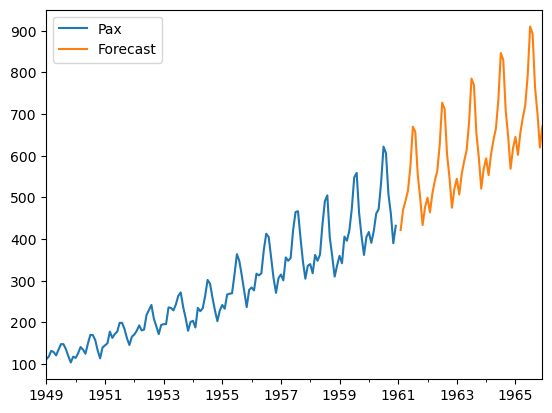

In [33]:
future_pred['Forecast']=result.predict(start=145,end=204, dynamic=True)
future_pred[['Pax','Forecast']].plot()
plt.show()

In [35]:
future_pred.tail(61)

,Pax,1st Diff,2nd Diff,Seasonality,Forecast
1960-12-01,432,42.0,113.0,27.0,NaN
1961-01-01,NaN,NaN,NaN,NaN,NaN
1961-02-01,NaN,NaN,NaN,NaN,421.798375
1961-03-01,NaN,NaN,NaN,NaN,469.995144
1961-04-01,NaN,NaN,NaN,NaN,492.214453
...,...,...,...,...,...
1965-08-01,NaN,NaN,NaN,NaN,892.832569
1965-09-01,NaN,NaN,NaN,NaN,765.064731
1965-10-01,NaN,NaN,NaN,NaN,701.777553
1965-11-01,NaN,NaN,NaN,NaN,619.725238


Here, we predicted, on that particular future date, these much of passangers will approximately we there.

- **Exporting the data to share with client**

In [36]:
future_pred.to_csv('AirlinePassengerForecasting.csv')

In [38]:
import os
os.getcwd()

#to check where the files has been exported.

'/Users/yashgurung/LearnBay/Time Series'